In [2]:
import os 
import torch
import random
from diffusers import StableDiffusionPipeline
from safetensors.torch import load_file
from copy import deepcopy
torch.set_grad_enabled(False)

/Users/fabio/miniconda3/envs/cs224r/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/fabio/miniconda3/envs/cs224r/lib/python3.9/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [3]:
torch_dtype = torch.float32
device = 'cpu'
basemodel_id="CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(basemodel_id, torch_dtype=torch_dtype, use_safetensors=True, safety_checker=None).to(device)
original_weights = deepcopy(pipe.unet.state_dict())
esd_weights = load_file("esd-stop_sign-from-stop_sign-esdu.safetensors")
esd_weights = {k: v.to(torch_dtype) for k, v in esd_weights.items()}

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 14.78it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


In [4]:
num_inference_steps = 20
guidance_scale = 7.5
height=width=512

100%|██████████| 20/20 [00:53<00:00,  2.69s/it]


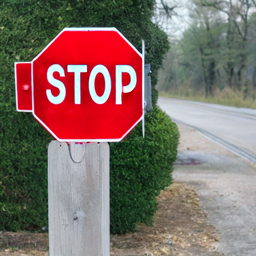

In [8]:
# Generate with original model
prompt = 'a stop sign'
seed = random.randint(0, 2**15)


pipe.unet.load_state_dict(original_weights, strict=False)
image = pipe(prompt, 
             num_inference_steps = num_inference_steps,
             guidance_scale= guidance_scale,
             height=height,
             width=width,
             generator=torch.Generator().manual_seed(seed)
            ).images
image[0].resize((256,256))

100%|██████████| 20/20 [00:53<00:00,  2.66s/it]


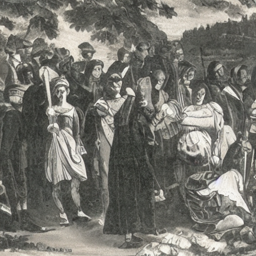

In [9]:
# Generate with ESD model
pipe.unet.load_state_dict(esd_weights, strict=False)
image = pipe(prompt, 
             num_inference_steps = num_inference_steps,
             guidance_scale= guidance_scale,
             height=height,
             width=width,
             generator=torch.Generator().manual_seed(seed)
            ).images
image[0].resize((256,256))